# Regularización de pesos

*Regularización* es el acto de aplicar cierta tecnica para evitar el overfiting. En particular *regularización de pesos* hace referencia al conjunto de tecnicas que asegura que los parametros de la red tomen cierto rango de valores aplicando una penalizacion a algunos valores (usualmente a los valores grandes). Hay 2 tecnicas populares para *regularización de pesos*:
- *L1 regularization*: A la funcion de error se le *suma el valor absoluto* del coeficiente del peso.
- *L2 regularization*: A la funcion de error se le *suma el cuadrado* del coeficiente del peso.

En las siguientes celdas se descarga y prepara el dataset de reseñas de peliculas IMDb y se muestran ejemplos de como aplicar cada una de estas *regularizaciones*.

# Data y preprocesing

Recuperación de los datos y preprocesarlos.

In [1]:
from keras.datasets import imdb

(train_data, train_labels), (test_data, test_labels) = imdb.load_data(
num_words=10000)

2025-07-22 20:58:12.669191: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1753228693.152707  537114 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1753228693.291775  537114 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1753228694.484908  537114 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1753228694.484986  537114 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1753228694.484995  537114 computation_placer.cc:177] computation placer alr

In [2]:
import numpy as np

"""Vectoriza un un conjunto de conjuntos de datos numericos en codificación ONE-HOT.
Persiste la información del contenido de cada conjunto pero se pierde todo lo relacionado
al orden y la cantidad de veces que aparece cada valor.

Keyword arguments:
sequences -- Conjunto de conjuntos de valores numericos.
dimension -- (def=10000) Cantidad de dimenciones a considerar para el tamaño de cada 
vectorizacion ONE-HOT.
Return: Conjunto de Conjuntos Vectorizado ONE-HOT
"""
def vectorize_sequences(sequences, dimension=10000):
    result = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        result[i, sequence] = 1
    return result
        
x_train = vectorize_sequences(train_data)
x_test = vectorize_sequences(test_data)

y_train = np.asarray(train_labels).astype('float32')
y_test = np.asarray(test_labels).astype('float32')

In [3]:
x_val = x_train[:10000]
partial_x_train = x_train[10000:]
y_val = y_train[:10000]
partial_y_train = y_train[10000:]

# Sin regularizar
Primero una muestra de validacion sin metodos de regularización para tener con que comparar mas adelante.

In [15]:
from tensorflow.keras import models
from tensorflow.keras import layers
from tensorflow.keras import regularizers

# Tamaños de modelo con los que realizar pruebas

model = models.Sequential()
model.add(layers.Dense(16, activation='relu', input_shape=(10000,)))
model.add(layers.Dense(16, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

model.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['acc'])

base_history = model.fit(
    partial_x_train,
    partial_y_train,
    epochs=20,
    batch_size=512,
    validation_data=(x_val, y_val))

base_val_loss_values = base_history.history['val_loss']
base_val_acc_values = base_history.history['val_acc']

/home/sponte/libros/dlwp/tf-gpu/lib/python3.10/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2025-07-22 21:06:17.420105: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 600000000 exceeds 10% of free system memory.


Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step - acc: 0.6744 - loss: 0.6283 - val_acc: 0.8548 - val_loss: 0.4485
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.8885 - loss: 0.3906 - val_acc: 0.8803 - val_loss: 0.3414
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - acc: 0.9119 - loss: 0.2817 - val_acc: 0.8889 - val_loss: 0.2963
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9310 - loss: 0.2198 - val_acc: 0.8897 - val_loss: 0.2809
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9468 - loss: 0.1786 - val_acc: 0.8901 - val_loss: 0.2745
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9593 - loss: 0.1466 - val_acc: 0.8876 - val_loss: 0.2850
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9624 - loss: 0.1275 - val_acc: 0.8841 - val_loss: 0.2889
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9713 - loss: 0.1040 - val_acc: 0.8824 - val_loss: 0.2993
Epoch 9/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9774

# Regularización L1

Construccion y evaluacion de modelo clasificador de reseñas de peliculas con *regularización L1*.

In [ ]:
from tensorflow.keras import models
from tensorflow.keras import layers
from tensorflow.keras import regularizers

model = models.Sequential()
model.add(layers.Dense(16, kernel_regularizer=regularizers.l1(0.0001), activation='relu', input_shape=(10000,)))
model.add(layers.Dense(16, kernel_regularizer=regularizers.l1(0.0001), activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

model.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['acc'])

history = model.fit(
    partial_x_train,
    partial_y_train,
    epochs=20,
    batch_size=512,
    validation_data=(x_val, y_val))

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 79ms/step - acc: 0.6627 - loss: 0.8059 - val_acc: 0.8510 - val_loss: 0.5627
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.8769 - loss: 0.5028 - val_acc: 0.8823 - val_loss: 0.4277
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - acc: 0.9094 - loss: 0.3715 - val_acc: 0.8847 - val_loss: 0.3821
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - acc: 0.9198 - loss: 0.3206 - val_acc: 0.8837 - val_loss: 0.3752
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9314 - loss: 0.2908 - val_acc: 0.8742 - val_loss: 0.3879
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9313 - loss: 0.2808 - val_acc: 0.8860 - val_loss: 0.3690
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9417 - loss: 0.2636 - val_acc: 0.8853 - val_loss: 0.3687
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9440 - loss: 0.2534 - val_acc: 0.8689 - val_loss: 0.4062
Epoch 9/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9401

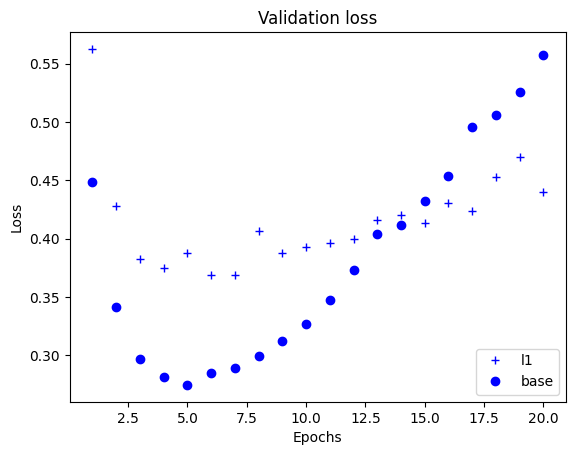

In [ ]:
import matplotlib.pyplot as plt

val_loss_values = history.history['val_loss']
epochs = range(1, len(val_loss_values) + 1)

plt.plot(epochs, val_loss_values, 'o', label="l1", color="blue")
plt.plot(epochs, base_val_loss_values, '+', label="base", color="blue")
plt.title('Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()


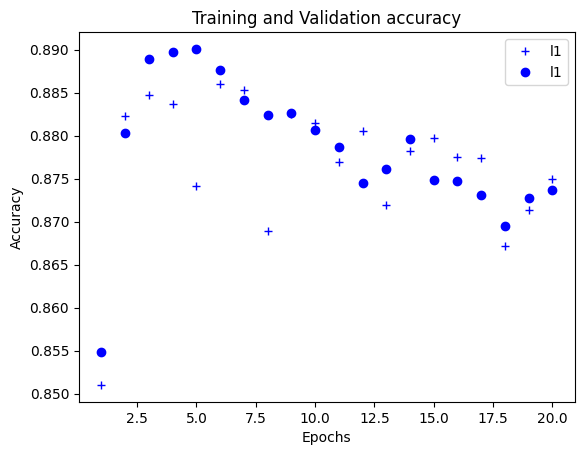

In [ ]:
import matplotlib.pyplot as plt

val_acc_values = history.history['val_acc']
epochs = range(1, len(val_acc_values) + 1)

plt.plot(epochs, val_acc_values, 'o', label="l1", color="blue")
plt.plot(epochs, base_val_acc_values, '+', label="base", color="blue")
plt.title('Training and Validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()


*Regularización L1* retraza el overfiting y hace que su pendiente sea menos pronunciada. No obstante tambien incrementa el error minimo y la presicion maxima. Visto desde afuera pareciera que tiene un efecto de redondeo hacia el promedio.

# Regularización L2

Construccion y evaluacion de modelo clasificador de reseñas de peliculas con *regularización L2*.

In [33]:
from tensorflow.keras import models
from tensorflow.keras import layers
from tensorflow.keras import regularizers

model = models.Sequential()
model.add(layers.Dense(16, kernel_regularizer=regularizers.l2(0.001), activation='relu', input_shape=(10000,)))
model.add(layers.Dense(16, kernel_regularizer=regularizers.l2(0.001), activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

model.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['acc'])

history = model.fit(
    partial_x_train,
    partial_y_train,
    epochs=20,
    batch_size=512,
    validation_data=(x_val, y_val))

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 84ms/step - acc: 0.6936 - loss: 0.6661 - val_acc: 0.8550 - val_loss: 0.4839
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.8764 - loss: 0.4307 - val_acc: 0.8818 - val_loss: 0.3843
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9044 - loss: 0.3361 - val_acc: 0.8850 - val_loss: 0.3493
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9229 - loss: 0.2867 - val_acc: 0.8886 - val_loss: 0.3353
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9326 - loss: 0.2546 - val_acc: 0.8846 - val_loss: 0.3412
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9431 - loss: 0.2324 - val_acc: 0.8740 - val_loss: 0.3677
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - acc: 0.9500 - loss: 0.2160 - val_acc: 0.8836 - val_loss: 0.3423
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9533 - loss: 0.2058 - val_acc: 0.8850 - val_loss: 0.3457
Epoch 9/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9599

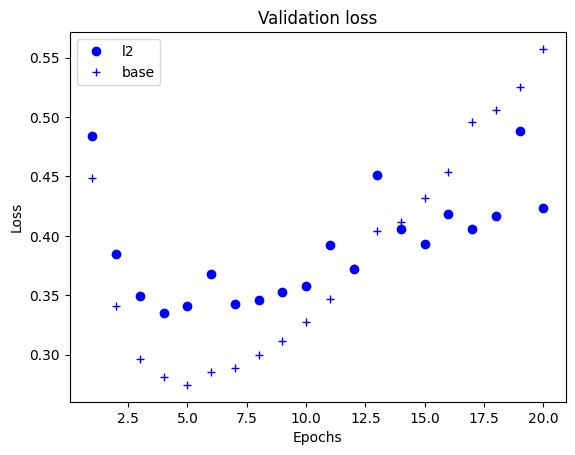

In [36]:
import matplotlib.pyplot as plt

val_loss_values = history.history['val_loss']
epochs = range(1, len(val_loss_values) + 1)

plt.plot(epochs, val_loss_values, 'o', label="l2", color="blue")
plt.plot(epochs, base_val_loss_values, '+', label="base", color="blue")
plt.title('Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

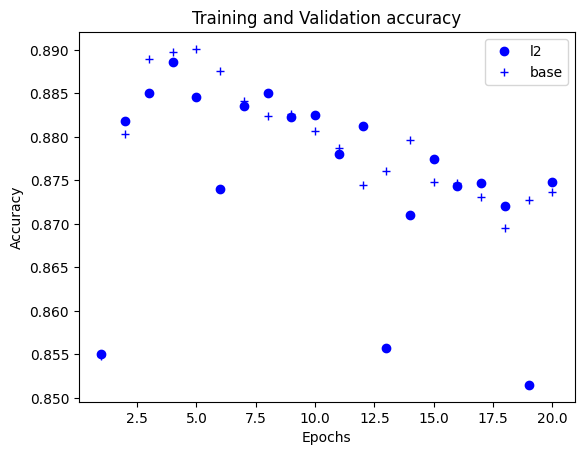

In [35]:
import matplotlib.pyplot as plt

val_acc_values = history.history['val_acc']
epochs = range(1, len(val_acc_values) + 1)

plt.plot(epochs, val_acc_values, 'o', label="l2", color="blue")
plt.plot(epochs, base_val_acc_values, '+', label="base", color="blue")
plt.title('Training and Validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

Efectos similares a lo  obtenido con *l1*, destacar que el valor usado para regularizar con *l2* con efectos similares fue 0.001 en vez de 0.00001.

# Regularización L1 y L2 Combinadas.

Es posible combinar las tecnicas de *regularizacion L1 y L2*.

In [40]:
from tensorflow.keras import models
from tensorflow.keras import layers
from tensorflow.keras import regularizers

model = models.Sequential()
model.add(layers.Dense(16, kernel_regularizer=regularizers.l1_l2(l1=0.00001, l2=0.001), activation='relu', input_shape=(10000,)))
model.add(layers.Dense(16, kernel_regularizer=regularizers.l1_l2(l1=0.00001, l2=0.001), activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

model.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['acc'])

history = model.fit(
    partial_x_train,
    partial_y_train,
    epochs=20,
    batch_size=512,
    validation_data=(x_val, y_val))

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 79ms/step - acc: 0.6773 - loss: 0.6892 - val_acc: 0.8601 - val_loss: 0.4891
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.8835 - loss: 0.4358 - val_acc: 0.8692 - val_loss: 0.4101
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9152 - loss: 0.3353 - val_acc: 0.8856 - val_loss: 0.3559
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - acc: 0.9278 - loss: 0.2836 - val_acc: 0.8903 - val_loss: 0.3387
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9361 - loss: 0.2527 - val_acc: 0.8797 - val_loss: 0.3524
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9460 - loss: 0.2280 - val_acc: 0.8831 - val_loss: 0.3506
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9495 - loss: 0.2215 - val_acc: 0.8821 - val_loss: 0.3578
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9572 - loss: 0.2039 - val_acc: 0.8843 - val_loss: 0.3486
Epoch 9/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9627

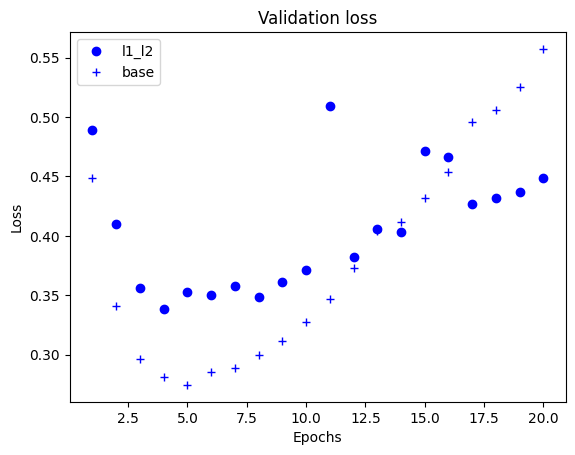

In [41]:
import matplotlib.pyplot as plt

val_loss_values = history.history['val_loss']
epochs = range(1, len(val_loss_values) + 1)

plt.plot(epochs, val_loss_values, 'o', label="l1_l2", color="blue")
plt.plot(epochs, base_val_loss_values, '+', label="base", color="blue")
plt.title('Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()


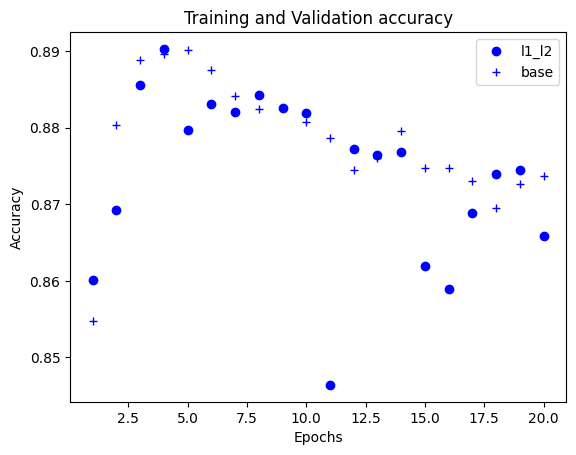

In [42]:
import matplotlib.pyplot as plt

val_acc_values = history.history['val_acc']
epochs = range(1, len(val_acc_values) + 1)

plt.plot(epochs, val_acc_values, 'o', label="l1_l2", color="blue")
plt.plot(epochs, base_val_acc_values, '+', label="base", color="blue")
plt.title('Training and Validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

El grafico obtenido en base a combinar ambos metodos de regularización es similar a lo obtenido al aplicar cada uno por separado. En este ejemplo no observo una ventaja al aplicarlo. 

GENERAL: El que mostro mejor resultado es *L2* pero la evidencia es circunstancial.